In [1]:
packages <- c("ggplot2", "dplyr", "patchwork", "viridis", "platetools")
for (pkg in packages) {
    if (!require(pkg, character.only = TRUE)) {

        suppressPackageStartupMessages(
            suppressWarnings(
                suppressMessages(
                    library(
                        pkg, character.only = TRUE
                    )
                )
            )
        )
    }
}
source("../../utils/r_themes.r")


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: patchwork

Loading required package: viridis

Warning message:
“package ‘viridis’ was built under R version 4.2.3”
Loading required package: viridisLite

Loading required package: platetools

Warning message:
“package ‘platetools’ was built under R version 4.2.3”


In [2]:
train_splits_df <- arrow::read_parquet("../data_splits/train.parquet")
test_splits_df <- arrow::read_parquet("../data_splits/test.parquet")
train_test_wells_df <- arrow::read_parquet("../data_splits/train_test_wells.parquet")

In [3]:
columns_to_keep <- c("Metadata_Well", "Metadata_dose")
train_splits_df <- train_splits_df %>% select(all_of(columns_to_keep))
test_splits_df <- test_splits_df %>% select(all_of(columns_to_keep))
# combine train and test splits for plotting
df <- rbind(
    train_splits_df,
    test_splits_df
)

df <- merge(
    df,
    train_test_wells_df,
)
# replace the "-" with ""
df$Metadata_Well <- gsub("-", "", df$Metadata_Well)
df$data_split <- gsub("train", "Train", df$data_split)
df$data_split <- gsub("test", "Test", df$data_split)
head(df)

,Metadata_Well,Metadata_dose,data_split
,<chr>,<dbl>,<chr>
1,C02,0.00,Train
2,C03,0.61,Train
3,C04,1.22,Test
4,C05,2.44,Train
5,C06,4.88,Train
6,C07,9.77,Train


Warning message:
“Warning: Your well label count ( 30 ) covers less than half the selected plate( 96 ).
Are you sure argument 'plate' is correct for the number of wells in your data?
note: Default is a 96-well plate.”


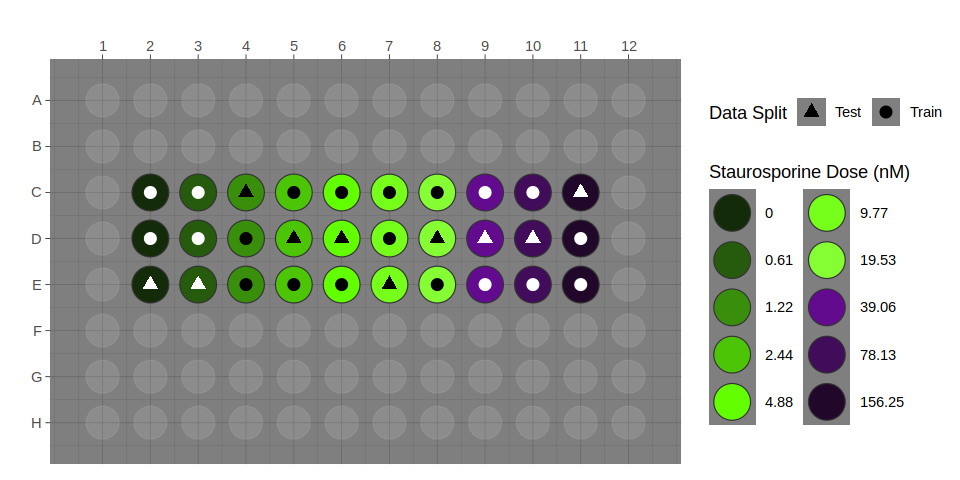

In [4]:
width <- 8
height <- 4
options(repr.plot.width = width, repr.plot.height = height)

# Extract column number from well label (e.g. "B04" -> 4)
df <- df %>%
  mutate(
    well_col  = as.integer(gsub(".*?(\\d+)$", "\\1", Metadata_Well)),  # ← base R
    col_group = case_when(
      well_col %in% 4:8           ~ "middle",
      well_col %in% c(1:3, 9:11) ~ "outer",
      TRUE                        ~ NA_character_
    )
  )

train_test_split_platemap_dose <- raw_map(
    data = factor(df$Metadata_dose),
    well = df$Metadata_Well,
    plate = 96
) +
  geom_point(
    aes(
      shape = factor(df$data_split),
      color = df$col_group          # ← map color to column group
    ),
    size = 3
  ) +
  theme_dark() +
  scale_fill_manual(values = color_palette_dose) +
  scale_shape_manual(values = c(17, 19)) +

  scale_color_manual(
    values = c("middle" = "black", "outer" = "white"),
    na.value = "grey50",
    guide = "none"              # ← removes color legend
)+
  labs(
    fill  = "Staurosporine Dose (nM)",
    shape = "Data Split",
    color = "Column Group"
  ) +
  guides(
    fill  = guide_legend(ncol = 2),
  shape = guide_legend(direction = "horizontal")  # ← horizontal shape legend  
  )
# save the figure
ggsave("../figures/train_test_split_platemap.png", train_test_split_platemap_dose, width = width, height = height, dpi = 600)
train_test_split_platemap_dose